In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("🚀 Starting Advanced Customer Segmentation & Clustering with EDA...")

# 1. Determine the dataset path dynamically in Kaggle
possible_paths = ['./', '/kaggle/input/brazilian-ecommerce/', '/kaggle/input/']
base_path = None
for path in possible_paths:
    if os.path.exists(os.path.join(path, 'olist_orders_dataset.csv')):
        base_path = path
        break

if base_path is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'olist_orders_dataset.csv' in files:
            base_path = root
            break

if base_path is None:
    raise FileNotFoundError("Olist files not found. Please ensure the dataset is attached to your Kaggle notebook.")

print(f"📂 Dataset found at: {base_path}")

# Load core files
customers = pd.read_csv(os.path.join(base_path, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(base_path, 'olist_orders_dataset.csv'))
reviews = pd.read_csv(os.path.join(base_path, 'olist_order_reviews_dataset.csv'))
items = pd.read_csv(os.path.join(base_path, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(base_path, 'olist_order_payments_dataset.csv'))

# 2. Convert dates and calculate logistics delay metrics
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Determine the absolute max date in the entire dataset
absolute_max_date = orders['order_purchase_timestamp'].max()

# Calculate actual delivery days and delivery delay days
orders['Actual_Delivery_Days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['Delivery_Delay_Days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['Delivery_Delay_Days'] = orders['Delivery_Delay_Days'].apply(lambda x: x if x > 0 else 0)

# 3. Aggregate payments and installments per order
order_payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

order_sales = items.groupby('order_id')['price'].sum().reset_index()

# Merge all tables together
df_merged = orders.merge(customers, on='customer_id', how='inner')
df_merged = df_merged.merge(order_sales, on='order_id', how='left')
df_merged = df_merged.merge(order_payments_agg, on='order_id', how='left')
df_merged = df_merged.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Handle missing values for clean metrics
df_merged['price'] = df_merged['price'].fillna(0)
df_merged['payment_value'] = df_merged['payment_value'].fillna(df_merged['price'])
df_merged['payment_installments'] = df_merged['payment_installments'].fillna(1)
df_merged['review_score'] = df_merged['review_score'].fillna(df_merged['review_score'].median())

# 4. Aggregation: Build behavioral and financial profiles per unique customer
customer_metrics = df_merged.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (absolute_max_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('price', 'sum'),
    Avg_Review_Score=('review_score', 'mean'),
    First_Purchase_Date=('order_purchase_timestamp', 'min'),
    Last_Purchase_Date=('order_purchase_timestamp', 'max'),
    Avg_Actual_Delivery_Days=('Actual_Delivery_Days', 'mean'),
    Avg_Delivery_Delay_Days=('Delivery_Delay_Days', 'mean'),
    Max_Payment_Installments=('payment_installments', 'max'),
    Total_Amount_Paid=('payment_value', 'sum'),
    Customer_City=('customer_city', 'first'),
    Customer_State=('customer_state', 'first')
).reset_index()

# Handle missing delivery averages
customer_metrics['Avg_Actual_Delivery_Days'] = customer_metrics['Avg_Actual_Delivery_Days'].fillna(customer_metrics['Avg_Actual_Delivery_Days'].median())
customer_metrics['Avg_Delivery_Delay_Days'] = customer_metrics['Avg_Delivery_Delay_Days'].fillna(0)

# Calculate days since last purchase independently
customer_metrics['Days_Since_Last_Purchase'] = (absolute_max_date - customer_metrics['Last_Purchase_Date']).dt.days

# =============================================================
# 📈 Step 4.5: Advanced Exploratory Data Analysis (EDA)
# =============================================================
print("\n" + "="*60)
print("📊 Running Comprehensive Exploratory Data Analysis (EDA)...")
print("="*60)

print(f"🔹 Merged Base Table Dimensions: {df_merged.shape[0]:,} rows | {df_merged.shape[1]} columns")
print(f"🔹 Unique Customers Found: {customer_metrics['customer_unique_id'].nunique():,}")

print("\n🔹 Numerical Features Summary (RFM & Reviews):")
print(customer_metrics[['Recency', 'Frequency', 'Monetary', 'Avg_Review_Score']].describe().round(2))

print("\n🔹 Customer Review Score Distribution:")
review_counts = df_merged['review_score'].value_counts().sort_index()
for score, count in review_counts.items():
    print(f"  - Review Score [{score}]: {count:,} orders")

print("\n🔹 Payment Installments Distribution Summary:")
print(customer_metrics['Max_Payment_Installments'].describe().round(2))

print("\n🔹 Logistics and Shipping Overview (In Days):")
print(customer_metrics[['Avg_Actual_Delivery_Days', 'Avg_Delivery_Delay_Days']].describe().round(2))

print("\n🔹 Top 5 States by Customer Concentration:")
top_states = customer_metrics['Customer_State'].value_counts().head(5)
for state, count in top_states.items():
    print(f"  - State [{state}]: {count:,} unique customers")

print("="*60 + "\n")

# =============================================================
# 🎯 Step 5: Define Business Segments & Run Clustering
# =============================================================
def business_segmentation(row):
    if row['Frequency'] > 1.5:
        return 'Loyal / Champion'
    elif row['Avg_Review_Score'] < 2.5:
        return 'Churned / Dissatisfied'
    elif row['Days_Since_Last_Purchase'] <= 120:
        return 'New Customer'
    else:
        return 'At Risk'

customer_metrics['Customer_Segment'] = customer_metrics.apply(business_segmentation, axis=1)

# Define the 120 days status for Power BI slicers
customer_metrics['120_Days_Status'] = np.where(customer_metrics['Days_Since_Last_Purchase'] > 120, 'Exceeded 120 Days (Inactive)', 'Within 120 Days (Active)')

# Unsupervised K-Means clustering
features_for_clustering = ['Recency', 'Frequency', 'Monetary', 'Avg_Review_Score']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_metrics[features_for_clustering])

print("🤖 Training K-Means model on core behaviors...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_metrics['Cluster'] = kmeans.fit_predict(scaled_features)

# Print comprehensive accuracy and behavioral report
print("\n" + "="*75)
print("📊 FINAL UPDATED CUSTOMER SEGMENTATION REPORT (4-MONTH / 120-DAY BASIS)")
print("="*75)
segment_counts = customer_metrics['Customer_Segment'].value_counts()
for segment, count in segment_counts.items():
    print(f" - Segment [{segment:<25}]: {count:,} customers")
print("="*75)

print("\n📈 Behavioral & Financial Averages Per Segment:")
view_cols = features_for_clustering + ['Days_Since_Last_Purchase', 'Max_Payment_Installments', 'Total_Amount_Paid']
print(customer_metrics.groupby('Customer_Segment')[view_cols].mean().round(2))
print("="*75 + "\n")

# Save final completed file for Power BI dashboard integration
output_file = 'olist_customer_segments_120_days.csv'
customer_metrics.to_csv(output_file, index=False)

print(f"🎯 Execution completed successfully!")
print(f"📁 Master Dashboard file saved as: ({output_file})")

🚀 Starting Advanced Customer Segmentation & Clustering with EDA...
📂 Dataset found at: /kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce

📊 Running Comprehensive Exploratory Data Analysis (EDA)...
🔹 Merged Base Table Dimensions: 99,992 rows | 18 columns
🔹 Unique Customers Found: 96,096

🔹 Numerical Features Summary (RFM & Reviews):
        Recency  Frequency  Monetary  Avg_Review_Score
count  96096.00   96096.00  96096.00          96096.00
mean     287.74       1.03    142.07              4.09
std      153.41       0.21    218.44              1.34
min        0.00       1.00      0.00              1.00
25%      163.00       1.00     46.00              4.00
50%      268.00       1.00     89.00              5.00
75%      397.00       1.00    154.99              5.00
max      772.00      17.00  13440.00              5.00

🔹 Customer Review Score Distribution:
  - Review Score [1.0]: 11,424 orders
  - Review Score [2.0]: 3,151 orders
  - Review Score [3.0]: 8,179 orders
  - R

🚀 Starting 4-Month (120 Days) Repeat Purchase Analysis...

📊 Updated 4-Month Statistics:
 - Total Repeat Purchases analyzed: 3,345
 - Purchases within 120 days (4 Months): 2,524
 - Percentage: 75.46%



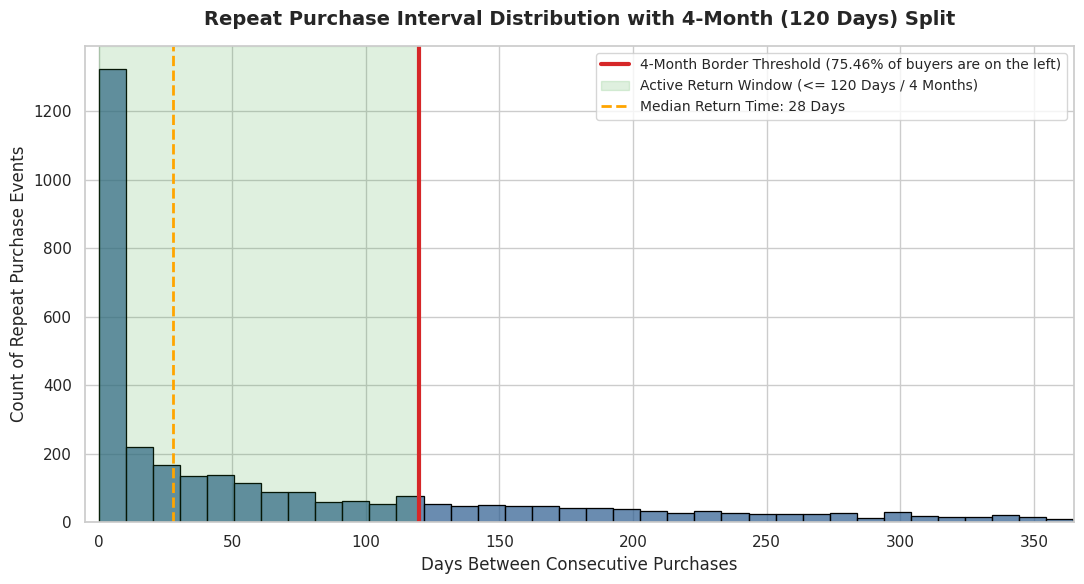

🎯 Plot displayed and saved successfully as: 'repeat_buyers_histogram_120_days.png'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("🚀 Starting 4-Month (120 Days) Repeat Purchase Analysis...")

# 1. Determine the dataset path dynamically in Kaggle
possible_paths = ['./', '/kaggle/input/brazilian-ecommerce/', '/kaggle/input/']
base_path = None
for path in possible_paths:
    if os.path.exists(os.path.join(path, 'olist_orders_dataset.csv')):
        base_path = path
        break

if base_path is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'olist_orders_dataset.csv' in files:
            base_path = root
            break

if base_path is None:
    raise FileNotFoundError("Olist files not found. Please ensure the dataset is attached.")

# Load core files
orders = pd.read_csv(os.path.join(base_path, 'olist_orders_dataset.csv'))
customers = pd.read_csv(os.path.join(base_path, 'olist_customers_dataset.csv'))

# Merge datasets to link orders with unique customers
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
df_merged = orders.merge(customers, on='customer_id', how='inner')

# 2. Filter and calculate intervals for repeat customers only
multi_orders = df_merged.groupby('customer_unique_id').filter(lambda x: len(x) > 1)
multi_orders = multi_orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# Calculate days between consecutive purchases for the same customer
multi_orders['Days_Between_Purchases'] = multi_orders.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days
days_between = multi_orders['Days_Between_Purchases'].dropna()

# 3. Calculate percentage of repeat buyers returning within 120 days (4 months)
total_repeat_events = len(days_between)
repeat_under_120 = len(days_between[days_between <= 120])
pct_repeat_under_120 = (repeat_under_120 / total_repeat_events) * 100

print(f"\n📊 Updated 4-Month Statistics:")
print(f" - Total Repeat Purchases analyzed: {total_repeat_events:,}")
print(f" - Purchases within 120 days (4 Months): {repeat_under_120:,}")
print(f" - Percentage: {pct_repeat_under_120:.2f}%\n")

# 4. Plot distribution with vertical line at 120 days
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Draw histogram and set range to 365 days to capture distribution clearly
sns.histplot(days_between, bins=60, color='#2b5c8f', edgecolor='black', alpha=0.7)

# Add vertical threshold line at 120 days
plt.axvline(120, color='#d62728', linestyle='-', linewidth=3, 
            label=f'4-Month Border Threshold ({pct_repeat_under_120:.2f}% of buyers are on the left)')

# Add highlighting span for the active window under 120 days
plt.axvspan(0, 120, color='#2ca02c', alpha=0.15, label='Active Return Window (<= 120 Days / 4 Months)')

# Add vertical line for the median return time
median_days = days_between.median()
plt.axvline(median_days, color='orange', linestyle='--', linewidth=2, label=f'Median Return Time: {median_days:.0f} Days')

# Configuration and labels
plt.title('Repeat Purchase Interval Distribution with 4-Month (120 Days) Split', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Days Between Consecutive Purchases', fontsize=12)
plt.ylabel('Count of Repeat Purchase Events', fontsize=12)
plt.xlim(-5, 365)  # Focus on a 1-year window
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()

# Save plot image and display output in Kaggle
plot_filename = 'repeat_buyers_histogram_120_days.png'
plt.savefig(plot_filename, dpi=300)
plt.show()

print(f"🎯 Plot displayed and saved successfully as: '{plot_filename}'")

In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("🚀 Starting Advanced 4-Month (120 Days) Customer Segmentation & Clustering...")

# 1. Determine the dataset path dynamically in Kaggle
possible_paths = ['./', '/kaggle/input/brazilian-ecommerce/', '/kaggle/input/']
base_path = None
for path in possible_paths:
    if os.path.exists(os.path.join(path, 'olist_orders_dataset.csv')):
        base_path = path
        break

if base_path is None:
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'olist_orders_dataset.csv' in files:
            base_path = root
            break

if base_path is None:
    raise FileNotFoundError("Olist files not found. Please ensure the dataset is attached to your Kaggle notebook.")

print(f"📂 Dataset found at: {base_path}")

# Load core files
customers = pd.read_csv(os.path.join(base_path, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(base_path, 'olist_orders_dataset.csv'))
reviews = pd.read_csv(os.path.join(base_path, 'olist_order_reviews_dataset.csv'))
items = pd.read_csv(os.path.join(base_path, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(base_path, 'olist_order_payments_dataset.csv'))

# 2. Convert dates and calculate logistics delay metrics
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Determine the absolute max date in the entire dataset
absolute_max_date = orders['order_purchase_timestamp'].max()

# Calculate actual delivery days and delivery delay days
orders['Actual_Delivery_Days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['Delivery_Delay_Days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['Delivery_Delay_Days'] = orders['Delivery_Delay_Days'].apply(lambda x: x if x > 0 else 0)

# 3. Aggregate payments and installments per order
order_payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

order_sales = items.groupby('order_id')['price'].sum().reset_index()

# Merge all tables together
df_merged = orders.merge(customers, on='customer_id', how='inner')
df_merged = df_merged.merge(order_sales, on='order_id', how='left')
df_merged = df_merged.merge(order_payments_agg, on='order_id', how='left')
df_merged = df_merged.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Handle missing values for clean metrics
df_merged['price'] = df_merged['price'].fillna(0)
df_merged['payment_value'] = df_merged['payment_value'].fillna(df_merged['price'])
df_merged['payment_installments'] = df_merged['payment_installments'].fillna(1)
df_merged['review_score'] = df_merged['review_score'].fillna(df_merged['review_score'].median())

# 4. Aggregation: Build behavioral and financial profiles per unique customer
print("⏳ Aggregating matrices and timelines per customer...")
customer_metrics = df_merged.groupby('customer_unique_id').agg(
    # Core behavioral features for K-Means (RFM)
    Recency=('order_purchase_timestamp', lambda x: (absolute_max_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('price', 'sum'),
    Avg_Review_Score=('review_score', 'mean'),
    
    # Date tracking fields
    First_Purchase_Date=('order_purchase_timestamp', 'min'),
    Last_Purchase_Date=('order_purchase_timestamp', 'max'),
    
    # Logistics and delay features
    Avg_Actual_Delivery_Days=('Actual_Delivery_Days', 'mean'),
    Avg_Delivery_Delay_Days=('Delivery_Delay_Days', 'mean'),
    
    # Financial metrics
    Max_Payment_Installments=('payment_installments', 'max'),
    Total_Amount_Paid=('payment_value', 'sum'),
    
    # Geographical features for Power BI maps
    Customer_City=('customer_city', 'first'),
    Customer_State=('customer_state', 'first')
).reset_index()

# Handle missing delivery averages
customer_metrics['Avg_Actual_Delivery_Days'] = customer_metrics['Avg_Actual_Delivery_Days'].fillna(customer_metrics['Avg_Actual_Delivery_Days'].median())
customer_metrics['Avg_Delivery_Delay_Days'] = customer_metrics['Avg_Delivery_Delay_Days'].fillna(0)

# Calculate days since last purchase independently
customer_metrics['Days_Since_Last_Purchase'] = (absolute_max_date - customer_metrics['Last_Purchase_Date']).dt.days

# 5. Define business segments based on the 4-month (120 days) threshold
def business_segmentation(row):
    if row['Frequency'] > 1.5:
        return 'Loyal / Champion'
    elif row['Avg_Review_Score'] < 2.5:
        return 'Churned / Dissatisfied'
    elif row['Days_Since_Last_Purchase'] <= 120:
        return 'New Customer'
    else:
        return 'At Risk'

customer_metrics['Customer_Segment'] = customer_metrics.apply(business_segmentation, axis=1)

# 6. Define the 120 days status for Power BI slicers
customer_metrics['120_Days_Status'] = np.where(customer_metrics['Days_Since_Last_Purchase'] > 120, 'Exceeded 120 Days (Inactive)', 'Within 120 Days (Active)')

# 7. Unsupervised K-Means clustering
features_for_clustering = ['Recency', 'Frequency', 'Monetary', 'Avg_Review_Score']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_metrics[features_for_clustering])

print("🤖 Training K-Means model on core behaviors...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_metrics['Cluster'] = kmeans.fit_predict(scaled_features)

# 8. Print comprehensive accuracy and behavioral report
print("\n" + "="*75)
print("📊 FINAL UPDATED CUSTOMER SEGMENTATION REPORT (4-MONTH / 120-DAY BASIS)")
print("="*75)
segment_counts = customer_metrics['Customer_Segment'].value_counts()
for segment, count in segment_counts.items():
    print(f" - Segment [{segment:<25}]: {count:,} customers")
print("="*75)

print("\n📈 Behavioral & Financial Averages Per Segment:")
view_cols = features_for_clustering + ['Days_Since_Last_Purchase', 'Max_Payment_Installments', 'Total_Amount_Paid']
print(customer_metrics.groupby('Customer_Segment')[view_cols].mean().round(2))
print("="*75 + "\n")

# 9. Save final completed file for Power BI dashboard integration
output_file = 'olist_customer_segments_120_days.csv'
customer_metrics.to_csv(output_file, index=False)

print(f"🎯 Execution completed successfully!")
print(f"📁 Master Dashboard file saved as: ({output_file})")

🚀 Starting Advanced 4-Month (120 Days) Customer Segmentation & Clustering...
📂 Dataset found at: /kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce
⏳ Aggregating matrices and timelines per customer...
🤖 Training K-Means model on core behaviors...

📊 FINAL UPDATED CUSTOMER SEGMENTATION REPORT (4-MONTH / 120-DAY BASIS)
 - Segment [At Risk                  ]: 66,460 customers
 - Segment [Churned / Dissatisfied   ]: 13,585 customers
 - Segment [New Customer             ]: 13,054 customers
 - Segment [Loyal / Champion         ]: 2,997 customers

📈 Behavioral & Financial Averages Per Segment:
                        Recency  Frequency  Monetary  Avg_Review_Score  \
Customer_Segment                                                         
At Risk                  327.20       1.00    134.80              4.57   
Churned / Dissatisfied   294.62       1.00    156.80              1.22   
Loyal / Champion         268.21       2.12    277.30              4.13   
New Customer          